In [150]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

In [151]:
def progonka(A, B, C, D):
    n = len(B) - 1
    al = [0] * (n + 1)
    be = [0] * (n + 1)
    al[0] = -C[0] / B[0]
    be[0] = D[0] / B[0]
    for i in range(1, n + 1):
        d = B[i] + A[i] * al[i - 1]
        if i < n:
            al[i] = -C[i] / d
        be[i] = (D[i] - A[i] * be[i - 1]) / d

    y = [0] * (n + 1)
    y[n] = be[n]
    for i in range(n - 1, -1, -1):
        y[i] = al[i] * y[i + 1] + be[i]
    return y

### Задачі 1.1-1.3

$$
y'' + e^{-x}y' + xy = x^2, \quad x \in [0,1]
$$

In [152]:
def p(x):
    return math.exp(-x)


def q(x):
    return x


def f(x):
    return x ** 2


def inner(n):
    h = 1 / n
    x = [i * h for i in range(n + 1)]
    A = [0] * (n + 1)
    B = [0] * (n + 1)
    C = [0] * (n + 1)
    D = [0] * (n + 1)
    for i in range(1, n):
        A[i] = 1 / h**2 - p(x[i]) / (2 * h)
        B[i] = -2 / h**2 + q(x[i])
        C[i] = 1 / h**2 + p(x[i]) / (2 * h)
        D[i] = f(x[i])
    return x, h, A, B, C, D


def plot_all(solver, title, sizes=(10, 100, 1000)):
    for n in sizes:
        x, y = solver(n)
        plt.plot(x, y, label=f"n = {n}")
        print(f"n = {n}: y(0.5) = {y[n // 2]:.8f}")
    plt.xlabel("x")
    plt.ylabel("y(x)")
    plt.title(title)
    plt.grid()
    plt.legend()
    plt.show()

### Task 1.1

$$
y(0) = 1, \quad y(1) = 0
$$

In [153]:
def task1(n):
    x, h, A, B, C, D = inner(n)
    B[0], D[0] = 1, 1          
    B[n], D[n] = 1, 0          
    return x, progonka(A, B, C, D)


x, y = task1(10)
for i in range(11):
    print(f"x = {x[i]:.2f}, y = {y[i]:.6f}")

x = 0.00, y = 1.000000
x = 0.10, y = 0.862456
x = 0.20, y = 0.736089
x = 0.30, y = 0.618631
x = 0.40, y = 0.508643
x = 0.50, y = 0.405367
x = 0.60, y = 0.308630
x = 0.70, y = 0.218762
x = 0.80, y = 0.136536
x = 0.90, y = 0.063114
x = 1.00, y = 0.000000


n = 10: y(0.5) = 0.40536694
n = 100: y(0.5) = 0.40481057
n = 1000: y(0.5) = 0.40480501


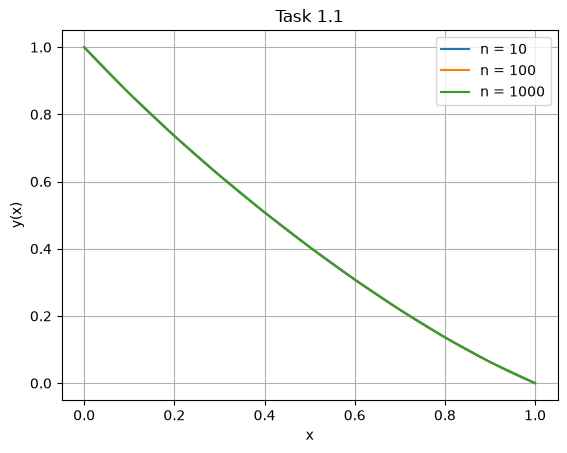

In [154]:
plot_all(task1, "Task 1.1")

### Task 1.2

$$
y'(0) = 1, \quad y'(1) = 0
$$

n = 10: y(0.5) = 2.08399627
n = 100: y(0.5) = 1.89647223
n = 1000: y(0.5) = 1.87992664


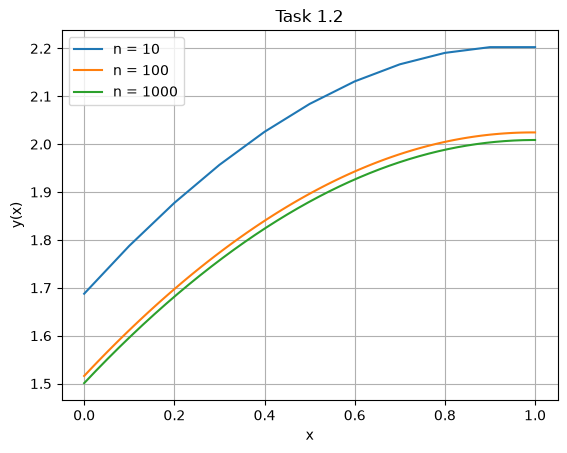

In [155]:
def task2(n):
    x, h, A, B, C, D = inner(n)
    B[0], C[0], D[0] = -1, 1, h * 1     # y'(0) = 1
    A[n], B[n], D[n] = -1, 1, h * 0     # y'(1) = 0
    return x, progonka(A, B, C, D)


plot_all(task2, "Task 1.2")

### Task 1.3

$$
2y(0) + y'(0) = 0, \quad 3y(1) + 2y'(1) = 1
$$

n = 10: y(0.5) = -0.00594814
n = 100: y(0.5) = -0.00593035
n = 1000: y(0.5) = -0.00586856


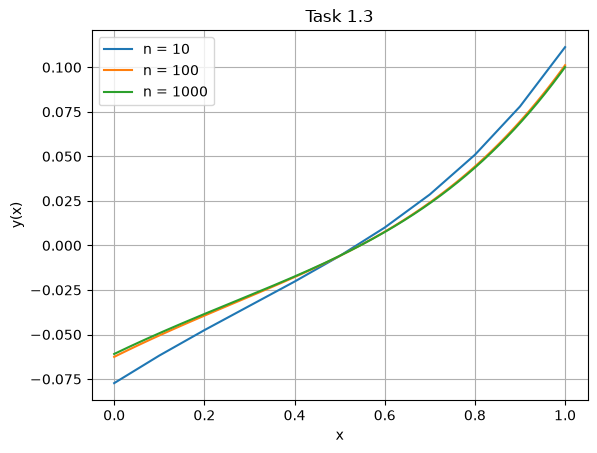

In [156]:
def task3(n):
    x, h, A, B, C, D = inner(n)
    B[0], C[0], D[0] = 2 * h - 1, 1, 0
    A[n], B[n], D[n] = -2, 3 * h + 2, h
    return x, progonka(A, B, C, D)


plot_all(task3, "Task 1.3")

### Task 2
$$
(k_x u_x)_x + (k_y u_y)_y + q u = f,
\quad x \in [1.1, 2.3],\ y \in [1, 2]
$$

In [157]:
def kx(x, y):
    return 1 + np.log(1 + x + y)


def ky(x, y):
    return 1 + np.sqrt(x**2 + y**2)


def q2(x, y):
    return -(x + y)


def f2(x, y):
    return np.cos(x + y)


def task4(nx, ny):
    hx = (2.3 - 1.1) / nx
    hy = (2 - 1) / ny
    x = np.linspace(1.1, 2.3, nx + 1)
    y = np.linspace(1, 2, ny + 1)

    def num(i, j):
        return i * (ny + 1) + j

    M = lil_matrix(((nx + 1) * (ny + 1), (nx + 1) * (ny + 1)))
    rhs = np.zeros((nx + 1) * (ny + 1))

    for i in range(nx + 1):
        for j in range(ny + 1):
            k = num(i, j)
            if i == 0:                      
                M[k, k] = 1
            elif j == 0:                   
                M[k, k] = 1
                rhs[k] = x[i]
            elif i == nx:                   
                M[k, k] = 2 - 3 / hx
                M[k, num(i - 1, j)] = 3 / hx
                rhs[k] = 1
            elif j == ny:                   
                M[k, k] = 1 / hy
                M[k, num(i, j - 1)] = -1 / hy
                rhs[k] = 1
            else:
                left = kx(x[i] - hx / 2, y[j]) / hx**2
                right = kx(x[i] + hx / 2, y[j]) / hx**2
                down = ky(x[i], y[j] - hy / 2) / hy**2
                up = ky(x[i], y[j] + hy / 2) / hy**2
                M[k, num(i - 1, j)] = left
                M[k, num(i + 1, j)] = right
                M[k, num(i, j - 1)] = down
                M[k, num(i, j + 1)] = up
                M[k, k] = -left - right - down - up - q2(x[i], y[j])
                rhs[k] = f2(x[i], y[j])

    u = spsolve(M.tocsr(), rhs).reshape((nx + 1, ny + 1))
    return x, y, u

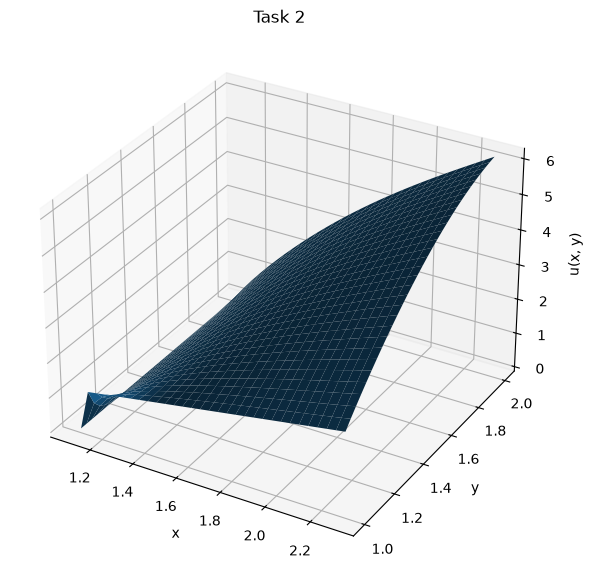

In [158]:
def surface(X, Y, u, title, zlabel="u(x, y)"):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(X, Y, u)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel(zlabel)
    ax.set_title(title)
    plt.show()


x, y, u = task4(30, 30)
X, Y = np.meshgrid(x, y, indexing="ij")
surface(X, Y, u, "Task 2")

In [159]:
for n in [10, 20, 40]:
    x, y, u = task4(n, n)
    print(f"{n}x{n}: u({x[n // 2]:.2f}, {y[n // 2]:.2f}) = {u[n // 2, n // 2]:.8f}")

10x10: u(1.70, 1.50) = 2.84602889
20x20: u(1.70, 1.50) = 2.91091998
40x40: u(1.70, 1.50) = 2.94542316


### Task 3

$$
u_{rr} + \frac{1}{r}u_r + \frac{1}{r^2}u_{\varphi\varphi} = f(r, \varphi),
\quad r \in [1, 2.2],\ \varphi \in [0, \pi/4]
$$

In [160]:
def f3(r, phi):
    return r * np.cos(phi) + np.sin(r)


def task5(nr, nphi):
    hr = (2.2 - 1.0) / nr
    hphi = (np.pi / 4) / nphi
    r = np.linspace(1.0, 2.2, nr + 1)
    phi = np.linspace(0, np.pi / 4, nphi + 1)

    def num(i, j):
        return i * (nphi + 1) + j

    M = lil_matrix(((nr + 1) * (nphi + 1), (nr + 1) * (nphi + 1)))
    rhs = np.zeros((nr + 1) * (nphi + 1))

    for i in range(nr + 1):
        for j in range(nphi + 1):
            k = num(i, j)
            if i == 0:
                M[k, k] = 1
            elif i == nr:
                M[k, k] = 1
                M[k, num(i - 1, j)] = -1
                rhs[k] = 2.2 * hr
            elif j == 0:
                M[k, k] = -2 * hphi - 1
                M[k, num(i, j + 1)] = 1
                rhs[k] = hphi
            elif j == nphi:
                M[k, k] = 2 * hphi + 3
                M[k, num(i, j - 1)] = -3
            else:
                ri = r[i]
                M[k, num(i - 1, j)] = 1 / hr**2 - 1 / (2 * ri * hr)
                M[k, num(i + 1, j)] = 1 / hr**2 + 1 / (2 * ri * hr)
                M[k, num(i, j - 1)] = 1 / (ri**2 * hphi**2)
                M[k, num(i, j + 1)] = 1 / (ri**2 * hphi**2)
                M[k, k] = -2 / hr**2 - 2 / (ri**2 * hphi**2)
                rhs[k] = f3(ri, phi[j])

    u = spsolve(M.tocsr(), rhs).reshape((nr + 1, nphi + 1))
    return r, phi, u

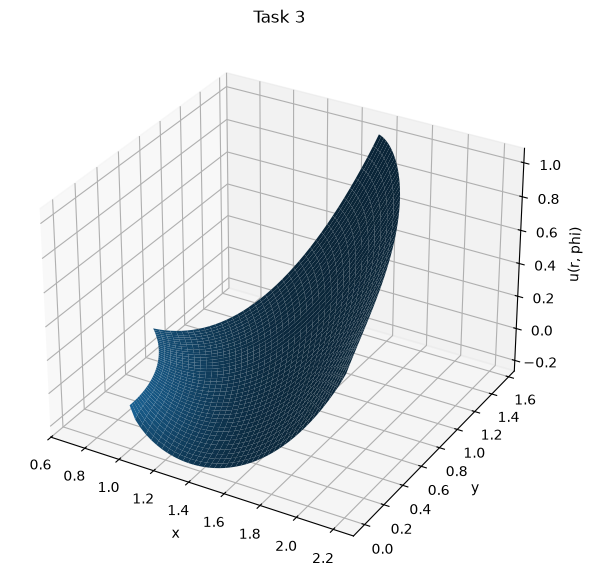

10x10: u(1.60, 0.3927) = 0.11046678
20x20: u(1.60, 0.3927) = 0.07737284
40x40: u(1.60, 0.3927) = 0.06058351


In [161]:
r, phi, u = task5(40, 40)
R, PHI = np.meshgrid(r, phi, indexing="ij")
surface(R * np.cos(PHI), R * np.sin(PHI), u, "Task 3", "u(r, phi)")

for n in [10, 20, 40]:
    r, phi, u = task5(n, n)
    print(f"{n}x{n}: u({r[n // 2]:.2f}, {phi[n // 2]:.4f}) = {u[n // 2, n // 2]:.8f}")

### Task 4

$$
u'' + \frac{1}{r}u' = \cos r, \quad u(1) = 0, \quad u'(2.2) = 1
$$

n = 10: u(1.60) = 1.11489366
n = 100: u(1.60) = 1.17198435
n = 1000: u(1.60) = 1.17779733


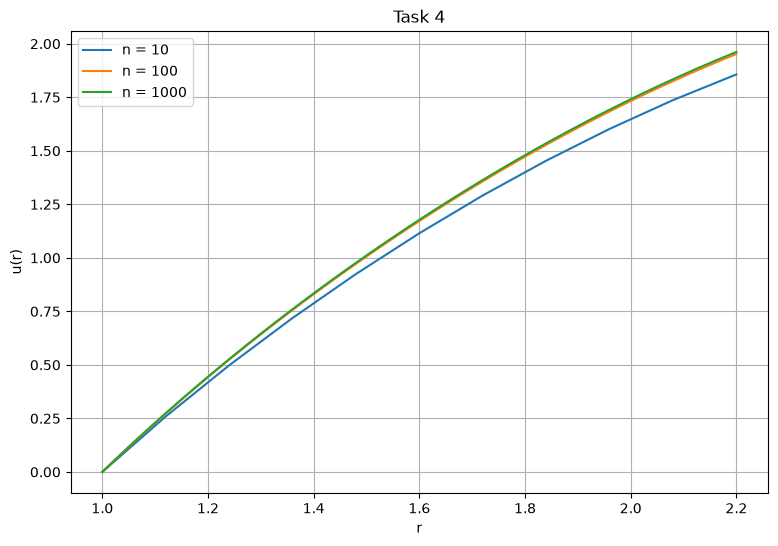

In [162]:
def task6(n):
    h = (2.2 - 1.0) / n
    r = np.linspace(1.0, 2.2, n + 1)
    A = [0] * (n + 1)
    B = [0] * (n + 1)
    C = [0] * (n + 1)
    D = [0] * (n + 1)

    B[0], D[0] = 1, 0                  # u(1) = 0
    A[n], B[n], D[n] = -1, 1, h        # u'(2.2) = 1
    for i in range(1, n):
        A[i] = 1 / h**2 - 1 / (2 * r[i] * h)
        B[i] = -2 / h**2
        C[i] = 1 / h**2 + 1 / (2 * r[i] * h)
        D[i] = np.cos(r[i])

    return r, progonka(A, B, C, D)


plt.figure(figsize=(9, 6))
for n in [10, 100, 1000]:
    r, u = task6(n)
    plt.plot(r, u, label=f"n = {n}")
    print(f"n = {n}: u({r[n // 2]:.2f}) = {u[n // 2]:.8f}")

plt.xlabel("r")
plt.ylabel("u(r)")
plt.title("Task 4")
plt.grid()
plt.legend()
plt.show()

### Task 5

$$
\Delta u = x^2 + y^2 + z^2, \quad (x, y, z) \in [0,1]^3
$$

In [163]:
def f5(x, y, z):
    return x**2 + y**2 + z**2


def task7(n):
    h = 1 / n
    t = np.linspace(0, 1, n + 1)

    def num(i, j, k):
        return i * (n + 1)**2 + j * (n + 1) + k

    N = (n + 1)**3
    M = lil_matrix((N, N))
    rhs = np.zeros(N)

    for i in range(n + 1):
        for j in range(n + 1):
            for k in range(n + 1):
                m = num(i, j, k)
                if i == n:                        
                    M[m, m] = 1
                elif j == n:                      
                    M[m, m] = 1
                    rhs[m] = 1
                elif k == n:                      
                    M[m, m] = 1
                elif i == 0:                      
                    M[m, m] = h - 1
                    M[m, num(i + 1, j, k)] = 1
                    rhs[m] = h
                elif j == 0:                      
                    M[m, m] = -1
                    M[m, num(i, j + 1, k)] = 1
                elif k == 0:                      
                    M[m, m] = h - 3
                    M[m, num(i, j, k + 1)] = 3
                    rhs[m] = h
                else:
                    for s in [num(i - 1, j, k), num(i + 1, j, k),
                              num(i, j - 1, k), num(i, j + 1, k),
                              num(i, j, k - 1), num(i, j, k + 1)]:
                        M[m, s] = 1 / h**2
                    M[m, m] = -6 / h**2
                    rhs[m] = f5(t[i], t[j], t[k])

    u = spsolve(M.tocsr(), rhs).reshape((n + 1, n + 1, n + 1))
    return t, u

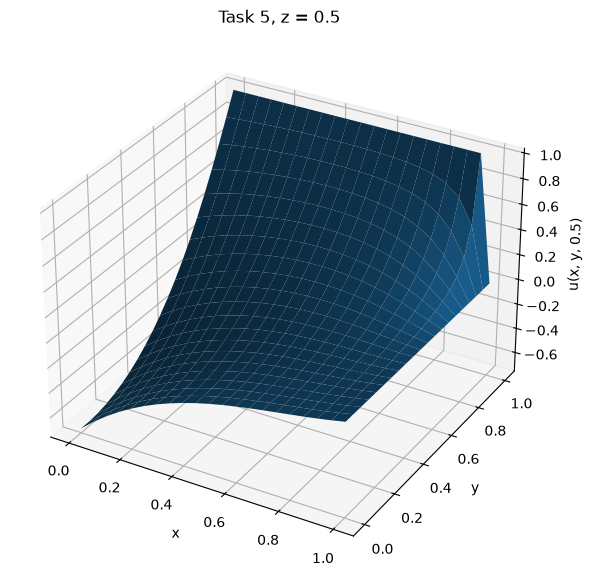

n = 6: u(0.5, 0.5, 0.5) = -0.00420998
n = 10: u(0.5, 0.5, 0.5) = 0.01884858
n = 20: u(0.5, 0.5, 0.5) = 0.03405902


In [164]:
n = 20
t, u = task7(n)
X, Y = np.meshgrid(t, t, indexing="ij")
surface(X, Y, u[:, :, n // 2], "Task 5, z = 0.5", "u(x, y, 0.5)")

for n in [6, 10, 20]:
    t, u = task7(n)
    print(f"n = {n}: u(0.5, 0.5, 0.5) = {u[n // 2, n // 2, n // 2]:.8f}")